# EMT/DP Ph3 GFL validation — diagnostics

This notebook contains development diagnostics that support internal model checking but are not part of the paper's main argument. The paper-facing figures remain in `EMT_DP_Ph3_GFL_StateSpaceValidation.ipynb`.

Use this notebook to inspect complete spectra, unmatched/global errors, all timestep records, initialization metadata, and anomalous branches. These results are deliberately separated because differences in model order make global nearest-spectrum metrics useful for detecting problems but weaker as publication validation evidence.


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

build_dir = Path("/home/gti/development/dpsim_local/dpsim/build/dpsim/examples/cxx")
result_dir = build_dir / "logs/EMT_DP_Ph3_GFL_StateSpaceValidation"
parameters = pd.read_csv(result_dir / "parameters.csv")
eigenvalues = pd.read_csv(result_dir / "eigenvalues.csv")
summary = pd.read_csv(result_dir / "summary.csv")
participation = pd.read_csv(result_dir / "participation.csv")
manifest_path = result_dir / "time_domain_manifest.csv"
time_manifest = pd.read_csv(manifest_path) if manifest_path.exists() else pd.DataFrame()
display(parameters)
display(summary.sort_values(["study", "time_step_us", "model"]))


,parameter,value,unit
0,frequency,5.000000e+01,Hz
1,apparent_power_base,1.200000e+07,VA
2,voltage_rms_ll,3.300000e+03,V
3,current_base_dq,3.636364e+03,A
4,impedance_base,9.075000e-01,ohm
5,inductance_base,2.888662e-03,H
6,capacitance_base,3.507547e-03,F
7,active_power_reference_pu,8.000000e-01,pu
8,reactive_power_reference_pu,1.000000e-01,pu
9,short_circuit_ratio,2.500000e+00,-


,study,model,kp_power_multiplier,time_step_s,time_step_us,state_count,extraction_sample_time_s,max_real_lambda,spectral_radius,reference_error,split_to_no_delay_deviation,reference_error_z
35,kp_power_sweep,DP Ph3 split,0.3500,0.000001,1,32,0.000001,-0.806302,0.999999,inf,216.632471,0.000217
39,kp_power_sweep,DP Ph3 split,0.3750,0.000001,1,32,0.000001,-0.806302,0.999999,inf,203.099545,0.000203
43,kp_power_sweep,DP Ph3 split,0.4000,0.000001,1,32,0.000001,-0.806302,0.999999,inf,187.988516,0.000188
47,kp_power_sweep,DP Ph3 split,0.4125,0.000001,1,32,0.000001,-0.806302,0.999999,inf,179.737135,0.000180
51,kp_power_sweep,DP Ph3 split,0.4250,0.000001,1,32,0.000001,-0.323578,1.000000,inf,170.949065,0.000171
...,...,...,...,...,...,...,...,...,...,...,...,...
24,time_step_sweep,EMT variable,0.4000,0.000500,500,20,0.000500,-0.806302,0.999597,225.433394,225.433394,0.025664
31,time_step_sweep,DP Ph3 split,0.4000,0.001000,1000,32,0.001000,33.229745,1.033788,inf,4968.036753,0.036361
30,time_step_sweep,DP Ph3 variable,0.4000,0.001000,1000,26,0.001000,-0.806302,0.999194,188.187822,188.187822,0.036423
29,time_step_sweep,EMT split,0.4000,0.001000,1000,20,0.001000,51.664780,1.053023,inf,4707.247931,0.079316


## Complete extracted spectra

These plots are branch-discovery diagnostics. They reveal duplicated envelope modes, sidebands, numerical modes, and branch crossings. They should not be used as a one-to-one validation metric when state dimensions differ.


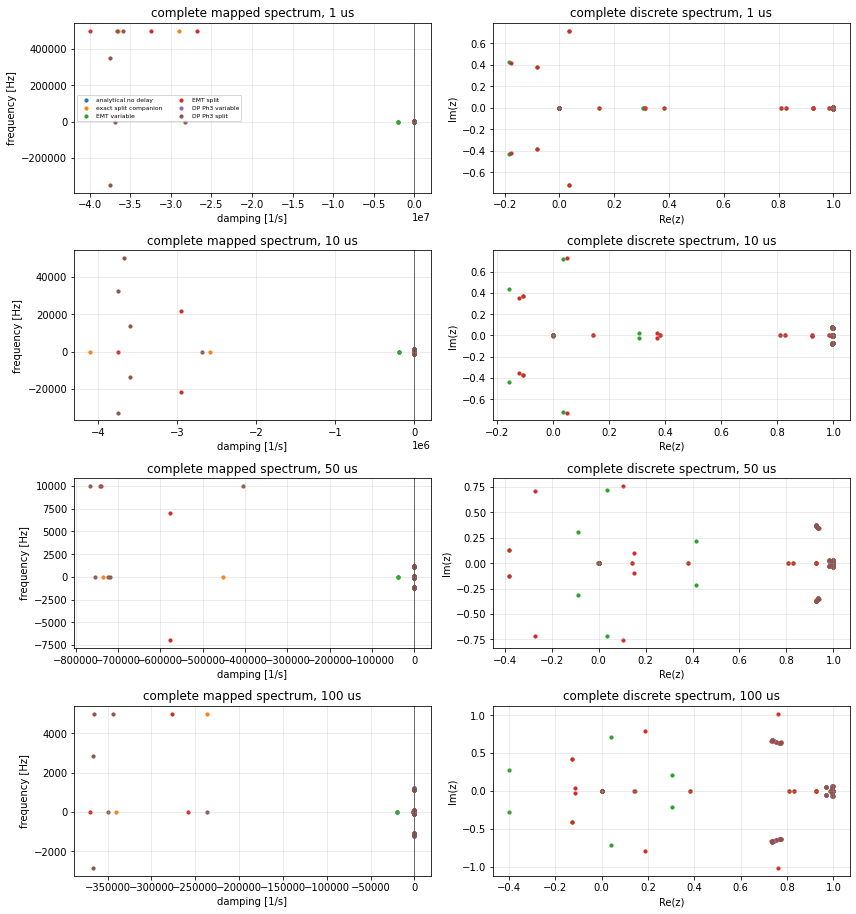

In [2]:
models = ["analytical no delay", "exact split companion",
          "EMT variable", "EMT split", "DP Ph3 variable", "DP Ph3 split"]
steps = [1.0, 10.0, 50.0, 100.0]
fig, axes = plt.subplots(len(steps), 2, figsize=(12, 3.2*len(steps)))
for row, dt_us in enumerate(steps):
    rows = eigenvalues[(eigenvalues.study == "time_step_sweep")
                       & np.isclose(eigenvalues.time_step_us, dt_us)]
    for model in models:
        selected = rows[rows.model == model]
        axes[row, 0].scatter(selected.lambda_real,
                             selected.lambda_imag/(2*np.pi), s=10, label=model)
        axes[row, 1].scatter(selected.z_real, selected.z_imag, s=10, label=model)
    axes[row, 0].axvline(0, color="0.3", lw=0.8)
    axes[row, 0].set(title=f"complete mapped spectrum, {dt_us:g} us",
                     xlabel="damping [1/s]", ylabel="frequency [Hz]")
    axes[row, 1].set(title=f"complete discrete spectrum, {dt_us:g} us",
                     xlabel="Re(z)", ylabel="Im(z)")
    for ax in axes[row]: ax.grid(alpha=0.3)
axes[0, 0].legend(fontsize=6, ncol=2)
fig.tight_layout(); plt.show()


## Global error and extraction diagnostics

The directed nearest-spectrum metrics below are intentionally diagnostic. A large value can expose a missing or unexpected mode, but it can also result from comparing a reduced $dq0$ reference with a model containing additional sidebands or packed states. Mode-specific continuation in the paper notebook carries the quantitative claim.


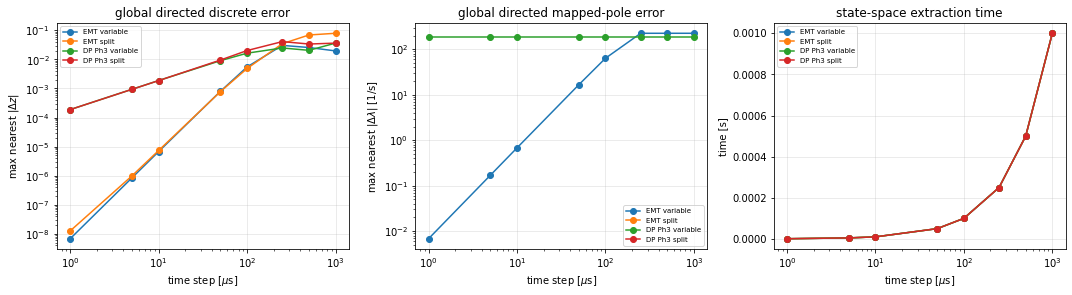

,study,model,kp_power_multiplier,time_step_s,time_step_us,state_count,extraction_sample_time_s,max_real_lambda,spectral_radius,reference_error,split_to_no_delay_deviation,reference_error_z
3,time_step_sweep,DP Ph3 split,0.4,0.000001,1,32,0.000001,-0.806302,0.999999,inf,187.988516,1.880148e-04
2,time_step_sweep,DP Ph3 variable,0.4,0.000001,1,26,0.000001,-0.806302,0.999999,188.187822,188.187822,1.881771e-04
1,time_step_sweep,EMT split,0.4,0.000001,1,20,0.000001,-0.806302,0.999999,inf,1.087304,1.263105e-08
0,time_step_sweep,EMT variable,0.4,0.000001,1,20,0.000001,-0.806302,0.999999,0.006809,0.006809,6.808500e-09
7,time_step_sweep,DP Ph3 split,0.4,0.000005,5,32,0.000005,-0.806303,0.999996,inf,186.596725,9.370753e-04
6,time_step_sweep,DP Ph3 variable,0.4,0.000005,5,26,0.000005,-0.806302,0.999996,188.187822,188.187822,9.404031e-04
5,time_step_sweep,EMT split,0.4,0.000005,5,20,0.000005,-0.806302,0.999996,inf,5.534648,9.929797e-07
4,time_step_sweep,EMT variable,0.4,0.000005,5,20,0.000005,-0.806302,0.999996,0.169948,0.169948,8.492677e-07
11,time_step_sweep,DP Ph3 split,0.4,0.000010,10,32,0.000010,-0.806302,0.999992,inf,183.528162,1.868821e-03
10,time_step_sweep,DP Ph3 variable,0.4,0.000010,10,26,0.000010,-0.806302,0.999992,188.187822,188.187822,1.878400e-03


In [3]:
sweep = summary[summary.study == "time_step_sweep"].copy()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for model in ["EMT variable", "EMT split", "DP Ph3 variable", "DP Ph3 split"]:
    rows = sweep[sweep.model == model].sort_values("time_step_us")
    axes[0].loglog(rows.time_step_us, rows.reference_error_z, "o-", label=model)
    axes[1].loglog(rows.time_step_us, rows.reference_error, "o-", label=model)
    axes[2].semilogx(rows.time_step_us, rows.extraction_sample_time_s, "o-", label=model)
axes[0].set(title="global directed discrete error", ylabel=r"max nearest $|\Delta z|$")
axes[1].set(title="global directed mapped-pole error", ylabel=r"max nearest $|\Delta\lambda|$ [1/s]")
axes[2].set(title="state-space extraction time", ylabel="time [s]")
for ax in axes:
    ax.set_xlabel(r"time step [$\mu$s]"); ax.grid(alpha=0.3); ax.legend(fontsize=7)
fig.tight_layout(); plt.show()
display(sweep.sort_values(["time_step_us", "model"]))


## Time-domain metadata and initialization diagnostics

The publication cases apply the pulse at $t=0$, so pre-disturbance errors are intentionally unavailable. This table remains useful for verifying that every model received the same documented pulse, duration, gain, timestep, and final time, and for inspecting older runs that used a pre-disturbance interval.


In [4]:
if time_manifest.empty:
    print("No time-domain manifest. Run the executable with --time-domain.")
else:
    display(time_manifest.sort_values(["stability_case", "time_step_us", "model"]))
    print("Unique perturbation times:", sorted(time_manifest.perturbation_time_s.unique()))
    print("Unique relative pulse amplitudes:", sorted(time_manifest.perturbation_relative.unique()))


No time-domain manifest. Run the executable with --time-domain.


## Detailed timestep-driven stability diagnostics

This section contains model-wide stability evidence and sideband detail intentionally omitted from paper Study 2. The three-phase spectrum contains 50 Hz-shifted copies of the electrical interaction. We therefore show the least-damped copy in the 0.8–1.5 kHz band at each timestep, together with the model-wide dominant growth rate. The former identifies the electrical branch envelope responsible for the 100 µs split instability; it is not raw-index continuation through sideband crossings.


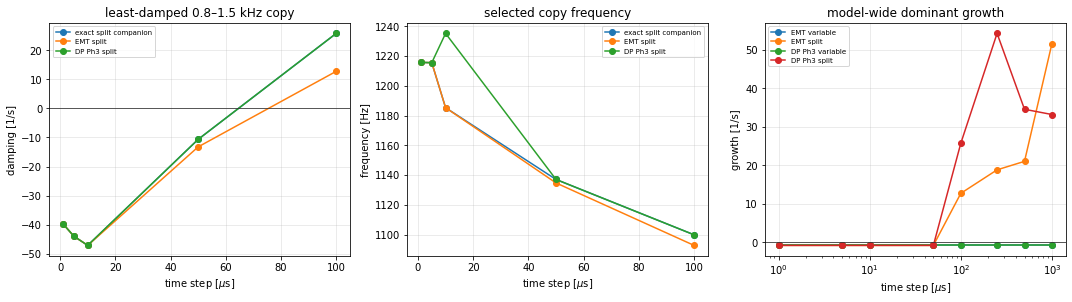

,model,time_step_us,damping,frequency_hz,radius
0,exact split companion,1,-39.616137,1215.711660,0.999960
1,exact split companion,5,-43.930324,1215.509729,0.999780
2,exact split companion,10,-47.075569,1185.268327,0.999529
3,exact split companion,50,-10.643556,1137.043829,0.999468
4,exact split companion,100,25.760244,1099.846853,1.002579
5,EMT split,1,-39.616772,1215.713668,0.999960
6,EMT split,5,-43.936258,1215.541330,0.999780
7,EMT split,10,-47.075569,1185.268327,0.999529
8,EMT split,50,-13.231126,1134.702344,0.999339
9,EMT split,100,12.732805,1092.729421,1.001274


In [5]:
method_for = {
    "analytical no delay": "trapezoidal",
    "exact split companion": "partitioned_trapezoidal",
    "EMT variable": "one_step", "EMT split": "one_step",
    "DP Ph3 variable": "one_step", "DP Ph3 split": "one_step",
}
branch_records = []
sideband_records = []
for model in ["exact split companion", "EMT split", "DP Ph3 split"]:
    for dt_us in sorted(eigenvalues.loc[
            eigenvalues.study == "time_step_sweep", "time_step_us"].unique()):
        if dt_us > 100.0:
            continue
        rows = eigenvalues[(eigenvalues.study == "time_step_sweep")
                           & (eigenvalues.model == model)
                           & (eigenvalues.method == method_for[model])
                           & np.isclose(eigenvalues.time_step_us, dt_us)].copy()
        rows = rows[np.isfinite(rows.lambda_real) & np.isfinite(rows.lambda_imag)
                    & (rows.lambda_imag > 2*np.pi*800.0)
                    & (rows.lambda_imag < 2*np.pi*1500.0)]
        if rows.empty:
            continue
        rows["frequency_hz"] = rows.lambda_imag/(2*np.pi)
        rows["radius"] = np.hypot(rows.z_real, rows.z_imag)
        for mode in rows.itertuples():
            sideband_records.append({"model": model, "time_step_us": dt_us,
                                     "damping": mode.lambda_real,
                                     "frequency_hz": mode.frequency_hz,
                                     "radius": mode.radius})
        mode = rows.loc[rows.lambda_real.idxmax()]
        branch_records.append({"model": model, "time_step_us": dt_us,
                               "damping": mode.lambda_real,
                               "frequency_hz": mode.frequency_hz,
                               "radius": mode.radius})
critical_branch = pd.DataFrame(branch_records)
electrical_sidebands = pd.DataFrame(sideband_records)

sweep = summary[summary.study == "time_step_sweep"].copy()
sweep["dominant_growth_1_per_s"] = np.log(sweep.spectral_radius)/sweep.time_step_s
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for model in critical_branch.model.unique():
    rows = critical_branch[critical_branch.model == model]
    axes[0].plot(rows.time_step_us, rows.damping, "o-", label=model)
    axes[1].plot(rows.time_step_us, rows.frequency_hz, "o-", label=model)
for model in ["EMT variable", "EMT split", "DP Ph3 variable", "DP Ph3 split"]:
    rows = sweep[sweep.model == model].sort_values("time_step_us")
    axes[2].semilogx(rows.time_step_us, rows.dominant_growth_1_per_s, "o-", label=model)
axes[0].axhline(0, color="0.2", lw=0.8)
axes[2].axhline(0, color="0.2", lw=0.8)
axes[0].set(title="least-damped 0.8–1.5 kHz copy", xlabel=r"time step [$\mu$s]", ylabel="damping [1/s]")
axes[1].set(title="selected copy frequency", xlabel=r"time step [$\mu$s]", ylabel="frequency [Hz]")
axes[2].set(title="model-wide dominant growth", xlabel=r"time step [$\mu$s]", ylabel="growth [1/s]")
for ax in axes: ax.grid(alpha=0.3); ax.legend(fontsize=7)
fig.tight_layout(); plt.show()
display(critical_branch)


## EMT-variable residual investigation

The paper results show a small but unexpected damping residual for the EMT variable model. This section tests four competing explanations before changing the solver:

1. a non-vanishing continuous-model or implementation mismatch;
2. discrete timestep error;
3. extraction phase or imperfect periodic initialization;
4. an error in the component's implemented analytical Jacobians.

The dedicated executable mode is:

```bash
./EMT_DP_Ph3_GFL_StateSpaceValidation --emt-variable-diagnostics
```


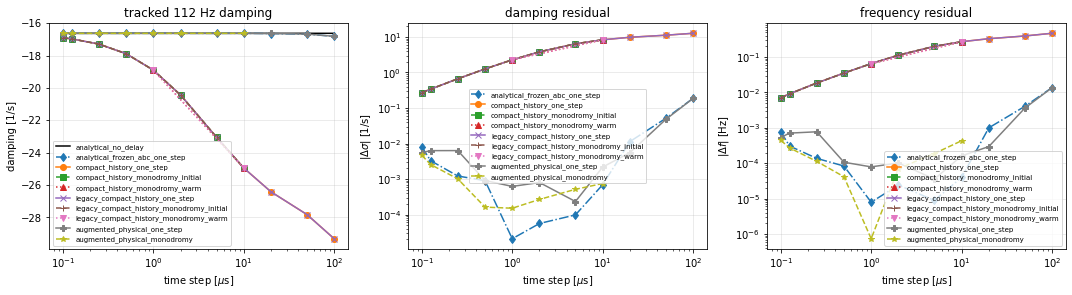

,quantity,value,unit
0,quadratic zero-step damping residual,-0.001292,1/s
1,smallest-step residual,-0.269958,1/s


,method,damping,frequency_hz,damping_residual,frequency_residual_hz
36,analytical_no_delay,-16.629371,112.120649,0.000000,0.000000e+00
39,compact_history_one_step,-18.901077,112.185870,-2.271706,6.522129e-02
40,compact_history_monodromy_initial,-18.901087,112.185849,-2.271716,6.520017e-02
42,legacy_compact_history_one_step,-18.901077,112.185870,-2.271706,6.522129e-02
45,augmented_physical_one_step,-16.629991,112.120728,-0.000620,7.898006e-05
46,augmented_physical_monodromy,-16.629522,112.120649,-0.000151,7.372838e-07


In [6]:
modal_diag = pd.read_csv(result_dir / "emt_variable_modal_diagnostics.csv")
jacobian_diag = pd.read_csv(result_dir / "emt_variable_jacobian_validation.csv")

def nearest_complex(rows, real, imag):
    distance = (rows.lambda_real-real)**2 + (rows.lambda_imag-imag)**2
    return rows.loc[distance.idxmin()]

tracked = []
for dt_us in sorted(modal_diag.loc[
        modal_diag.diagnostic == "timestep_convergence", "time_step_us"].unique()):
    reference_rows = modal_diag[(modal_diag.diagnostic == "timestep_convergence")
                                & (modal_diag.method == "analytical_no_delay")
                                & np.isclose(modal_diag.time_step_us, dt_us)
                                & (modal_diag.lambda_imag > 0)]
    reference = nearest_complex(reference_rows, -16.63, 2*np.pi*112.12)
    methods = modal_diag[(modal_diag.diagnostic == "timestep_convergence")
                         & np.isclose(modal_diag.time_step_us, dt_us)].method.unique()
    for method in methods:
        candidates = modal_diag[(modal_diag.diagnostic == "timestep_convergence")
                                & (modal_diag.method == method)
                                & np.isclose(modal_diag.time_step_us, dt_us)].copy()
        if "monodromy" in method:
            lifted = []
            for candidate in candidates.itertuples():
                for harmonic in range(-5, 6):
                    lifted.append((candidate.lambda_real,
                                   candidate.lambda_imag + harmonic*2*np.pi*50))
            lifted = np.asarray(lifted)
            index = np.argmin((lifted[:,0]-reference.lambda_real)**2
                              + (lifted[:,1]-reference.lambda_imag)**2)
            damping, angular_frequency = lifted[index]
        else:
            candidates = candidates[candidates.lambda_imag > 0]
            mode = nearest_complex(candidates, reference.lambda_real,
                                   reference.lambda_imag)
            damping, angular_frequency = mode.lambda_real, mode.lambda_imag
        tracked.append({"time_step_us": dt_us, "method": method,
                        "damping": damping,
                        "frequency_hz": angular_frequency/(2*np.pi),
                        "damping_residual": damping-reference.lambda_real,
                        "frequency_residual_hz": angular_frequency/(2*np.pi)
                                                 - reference.lambda_imag/(2*np.pi)})
tracked = pd.DataFrame(tracked)

small = tracked[(tracked.method == "compact_history_one_step") & (tracked.time_step_us <= 1.0)]
quadratic = np.polyfit(small.time_step_us, small.damping_residual, 2)
zero_step_residual = np.polyval(quadratic, 0.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for method, style in [("analytical_no_delay", "k-"),
                      ("analytical_frozen_abc_one_step", "d-."),
                      ("compact_history_one_step", "o-"),
                      ("compact_history_monodromy_initial", "s--"),
                      ("compact_history_monodromy_warm", "^:"),
                      ("legacy_compact_history_one_step", "x-"),
                      ("legacy_compact_history_monodromy_initial", "+--"),
                      ("legacy_compact_history_monodromy_warm", "v:"),
                      ("augmented_physical_one_step", "P-"),
                      ("augmented_physical_monodromy", "*--")]:
    rows = tracked[tracked.method == method].sort_values("time_step_us")
    if rows.empty: continue
    axes[0].semilogx(rows.time_step_us, rows.damping, style, label=method)
    if method != "analytical_no_delay":
        axes[1].loglog(rows.time_step_us, np.abs(rows.damping_residual),
                       style, label=method)
        axes[2].loglog(rows.time_step_us, np.abs(rows.frequency_residual_hz),
                       style, label=method)
axes[0].set(ylabel="damping [1/s]", title="tracked 112 Hz damping")
axes[1].set(ylabel=r"$|\Delta\sigma|$ [1/s]", title="damping residual")
axes[2].set(ylabel=r"$|\Delta f|$ [Hz]", title="frequency residual")
for ax in axes:
    ax.set_xlabel(r"time step [$\mu$s]"); ax.grid(alpha=.3); ax.legend(fontsize=7)
fig.tight_layout(); plt.show()

display(pd.DataFrame({
    "quantity": ["quadratic zero-step damping residual", "smallest-step residual"],
    "value": [zero_step_residual,
              small.loc[small.time_step_us.idxmin(), "damping_residual"]],
    "unit": ["1/s", "1/s"],
}))

comparison_1us = tracked[np.isclose(tracked.time_step_us, 1.0) & tracked.method.isin([
    "analytical_no_delay", "compact_history_one_step",
    "legacy_compact_history_one_step",
    "augmented_physical_one_step", "compact_history_monodromy_initial",
    "augmented_physical_monodromy"])][
        ["method", "damping", "frequency_hz", "damping_residual",
         "frequency_residual_hz"]]
display(comparison_1us)


### Interpretation: timestep dependence

The residual decreases monotonically from approximately $-2.27\,\mathrm{s^{-1}}$ at 1 µs to $-0.27\,\mathrm{s^{-1}}$ at 0.1 µs. A quadratic fit over 0.1–1 µs extrapolates to a residual close to zero. One-step and Floquet results remain coincident. The independently assembled legacy `EMT::Ph3::AvVoltSourceInverterStateSpace` produces the same tracked eigenvalue as the newer `EMT::Ph3::SSN_GFL` to numerical precision across the sweep.

This is evidence for a finite-step effect in the former compact EMT-variable extraction coordinate, rather than a different continuous-time mode or logarithmic pole-conversion error. A control calculation that transforms the analytical model to native abc coordinates, freezes it for one trapezoidal step, and transforms it back remains close to the reference. The production augmented realization $[x,u_{\mathrm{previous}}]$ removes the residual: at 1 µs it changes the extracted damping from approximately $-18.901$ to $-16.630\,\mathrm{s^{-1}}$, against the $-16.629\,\mathrm{s^{-1}}$ reference.

This directly implicates the former compact history-coordinate realization, which remains available only as a diagnostic control. Its derivation identifies consecutive history states using the same $A_d$ and $B_d$. For an EMT component whose matrices rotate and are rebuilt every step, that coordinate changes between steps. Multiplying the resulting matrices as if the coordinate were fixed creates the observed first-order modal residual. The extrapolation remains diagnostic evidence, not a paper result.


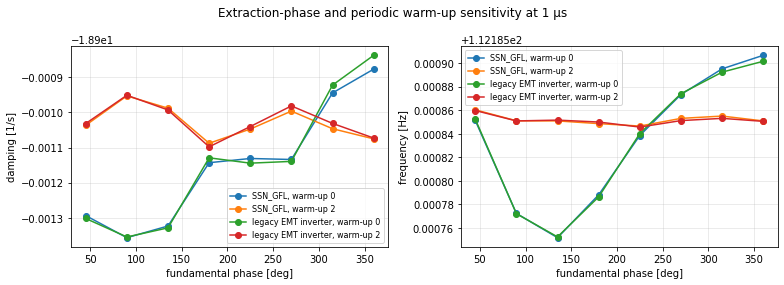

damping_min  damping_max  frequency_min  \
implementation      warmup_periods                                            
SSN_GFL             0                -18.901357   -18.900877     112.185752   
                    2                -18.901088   -18.900953     112.185846   
legacy EMT inverter 0                -18.901355   -18.900837     112.185752   
                    2                -18.901098   -18.900951     112.185846   

                                    frequency_max  
implementation      warmup_periods                 
SSN_GFL             0                  112.185907  
                    2                  112.185860  
legacy EMT inverter 0                  112.185901  
                    2                  112.185860

In [7]:
phase_rows = modal_diag[modal_diag.diagnostic == "phase_sweep"]
phase_records = []
for method, implementation in [("compact_history_one_step", "SSN_GFL"),
                               ("legacy_compact_history_one_step", "legacy EMT inverter")]:
    for warmup in sorted(phase_rows.warmup_periods.unique()):
        for phase in sorted(phase_rows.loc[
                phase_rows.warmup_periods == warmup, "phase_deg"].unique()):
            candidates = phase_rows[(phase_rows.method == method)
                                    & (phase_rows.warmup_periods == warmup)
                                    & np.isclose(phase_rows.phase_deg, phase)
                                    & (phase_rows.lambda_imag > 0)]
            mode = nearest_complex(candidates, -18.9, 2*np.pi*112.18)
            phase_records.append({"implementation": implementation,
                                  "warmup_periods": warmup, "phase_deg": phase,
                                  "damping": mode.lambda_real,
                                  "frequency_hz": mode.lambda_imag/(2*np.pi)})
phase_modes = pd.DataFrame(phase_records)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for (implementation, warmup), rows in phase_modes.groupby(
        ["implementation", "warmup_periods"]):
    label = f"{implementation}, warm-up {warmup}"
    axes[0].plot(rows.phase_deg, rows.damping, "o-", label=label)
    axes[1].plot(rows.phase_deg, rows.frequency_hz, "o-", label=label)
axes[0].set(ylabel="damping [1/s]"); axes[1].set(ylabel="frequency [Hz]")
for ax in axes:
    ax.set_xlabel("fundamental phase [deg]"); ax.grid(alpha=.3); ax.legend(fontsize=8)
fig.suptitle("Extraction-phase and periodic warm-up sensitivity at 1 µs")
fig.tight_layout(); plt.show()

phase_summary = phase_modes.groupby(["implementation", "warmup_periods"]).agg(
    damping_min=("damping", "min"), damping_max=("damping", "max"),
    frequency_min=("frequency_hz", "min"), frequency_max=("frequency_hz", "max"))
display(phase_summary)


### Interpretation: phase and warm-up

The tracked damping is practically phase invariant, and two warm-up periods do not remove the residual. The legacy and new EMT implementations overlap. Consequently, neither extraction timestamp, failure to reach a periodic orbit, nor code specific to the new `SSN_GFL` implementation explains the observed difference.


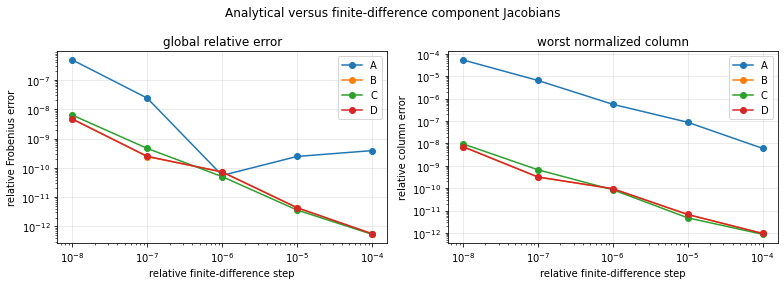

matrix,A,B,C,D
phase_deg,,,,
0.0,5.518167e-11,7.233741e-11,5.016982e-11,7.260738e-11
90.0,3.218605e-10,5.003124e-11,5.582553e-11,4.955299e-11
180.0,6.979653e-10,4.669231e-11,5.015240e-11,4.642139e-11
270.0,4.791473e-10,3.897546e-11,2.912656e-11,3.879188e-11
360.0,7.490917e-10,4.992006e-11,7.821332e-11,4.847321e-11


In [8]:
initial = jacobian_diag[jacobian_diag.phase_deg == 0.0]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for matrix in ["A", "B", "C", "D"]:
    rows = initial[initial.matrix == matrix].sort_values("relative_step")
    axes[0].loglog(rows.relative_step, rows.relative_frobenius_error, "o-", label=matrix)
    axes[1].loglog(rows.relative_step, rows.max_column_relative_error, "o-", label=matrix)
axes[0].set(title="global relative error", ylabel="relative Frobenius error")
axes[1].set(title="worst normalized column", ylabel="relative column error")
for ax in axes:
    ax.set_xlabel("relative finite-difference step"); ax.grid(alpha=.3); ax.legend()
fig.suptitle("Analytical versus finite-difference component Jacobians")
fig.tight_layout(); plt.show()

phase_jacobian = jacobian_diag[np.isclose(jacobian_diag.relative_step, 1e-6)]
display(phase_jacobian.pivot(index="phase_deg", columns="matrix",
                             values="relative_frobenius_error"))


In [9]:
map_validation = pd.read_csv(result_dir / "emt_variable_one_step_map_validation.csv")
display(map_validation)

fd_rows = modal_diag[(modal_diag.diagnostic == "one_step_map_validation")
                     & (modal_diag.method == "finite_difference_actual_one_step")
                     & (modal_diag.lambda_imag > 0)]
fd_mode = nearest_complex(fd_rows, -16.63, 2*np.pi*112.12)
display(pd.DataFrame({
    "quantity": ["finite-difference damping", "finite-difference frequency"],
    "value": [fd_mode.lambda_real, fd_mode.lambda_imag/(2*np.pi)],
    "unit": ["1/s", "Hz"],
}))


,relative_step,max_absolute_error,max_relative_column_error,relative_frobenius_error
0,0.000100,0.010687,0.000322,0.000301
1,0.000030,0.010687,0.000322,0.000301
2,0.000010,0.010686,0.000322,0.000302
3,0.000003,0.010688,0.000322,0.000301
4,0.000001,0.010689,0.000322,0.000302


,quantity,value,unit
0,finite-difference damping,-16.646416,1/s
1,finite-difference frequency,112.122499,Hz


### End-to-end one-step-map validation

The complete nonlinear EMT simulation step was differentiated by central differences in the augmented coordinate $[h_{L_g},x,u_{\mathrm{previous}}]$. The error is insensitive to the finite-difference step, so the comparison is numerically resolved. Although small differences remain in the complete matrix because the simulation relinearizes its nonlinear affine model for every perturbed run, the relevant mode is $-16.646\,\mathrm{s^{-1}}$ at $112.1225\,\mathrm{Hz}$. This agrees closely with the production augmented extraction ($-16.630\,\mathrm{s^{-1}}$, $112.1207\,\mathrm{Hz}$) and the analytical reference ($-16.629\,\mathrm{s^{-1}}$, $112.1206\,\mathrm{Hz}$). The former compact extraction ($-18.901\,\mathrm{s^{-1}}$, $112.1859\,\mathrm{Hz}$) is not the tangent of the actual step for this mode.


### Current diagnosis and required correction

The analytical component Jacobians agree with central finite differences across the fundamental period. The legacy inverter's identical result independently checks the new component's equation assembly. Together, the tests above rule out the leading initialization, phase, pole-mapping, and component-specific local-Jacobian explanations.

The augmented-coordinate control confirms that the former compact extraction misses the changing history-coordinate definition. The shared EMT variable-SSN contributor now uses the augmented physical coordinate by default; this is not an `SSN_GFL`-specific correction and does not require solver iteration.

The implemented production choice is:

1. use the augmented physical realization $[x,u_{\mathrm{previous}}]$ for variable voltage-type SSN extraction; this is simple and explicit but adds three extraction states per three-phase component.

The end-to-end finite-difference result validates this transition for the relevant mode. An exact compact conversion could be investigated later as an optimization, but it is no longer used for production extraction.
